### 1. 멋진 단어사전 만들기

In [1]:
import MeCab

mecab = MeCab.Tagger()
print(mecab.parse('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

자연어	NNG,*,F,자연어,Compound,*,*,자연/NNG/*+어/NNG/*
처리	NNG,행위,F,처리,*,*,*,*
가	JKS,*,F,가,*,*,*,*
너무	MAG,성분부사|정도부사,F,너무,*,*,*,*
재밌	VA,*,T,재밌,*,*,*,*
어서	EC,*,F,어서,*,*,*,*
밥	NNG,*,T,밥,*,*,*,*
먹	VV,*,T,먹,*,*,*,*
는	ETM,*,T,는,*,*,*,*
것	NNB,*,T,것,*,*,*,*
도	JX,*,F,도,*,*,*,*
가끔	MAG,성분부사|시간부사,T,가끔,*,*,*,*
까먹	VV,*,T,까먹,*,*,*,*
어요	EF,*,F,어요,*,*,*,*
EOS



### 2. 데이터 다운로드 및 분석

In [2]:
import os

import matplotlib.pyplot as plt
import torch
import numpy as np

%matplotlib inline

In [ ]:
import os
path_to_file = os.path.expanduser("~/work/sentiment_classification/data/korean-english-park.train.ko")

with open(path_to_file, "r", encoding="utf-8") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))

print("Example:")
for sen in raw[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


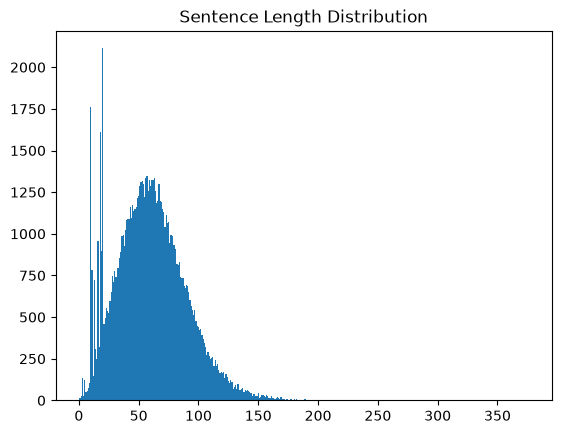

In [12]:
min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(raw))

sentence_length = np.zeros((max_len), dtype=int)

for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [13]:
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

check_sentence_with_length(raw, 1)

’


In [14]:
for idx, _sum in enumerate(sentence_length):
    # 문장의 수가 1500을 초과하는 문장 길이를 추출합니다.
    if _sum > 1500:
        print("Outlier Index:", idx+1)

Outlier Index: 11
Outlier Index: 19
Outlier Index: 21


In [15]:
check_sentence_with_length(raw, 11)

라고 조던이 말했다.
- 모르고 있습니다.
- 네, 보이는군요.
디즈니사만이 아니다.
큰 파티는 아니지요.
의자는 비어 있었다.
이 일은 계속됩니다.
나는 크게 실망했다.
그 이유는 간단하다.
이력서와 자기 소개서
시대가 변하고 있다.
는 돌발질문을 했다.
9. 몇 분간의 명상
하와이, 빅 아일랜드
키스를 잘 하는 방법
키스를 잘 하는 방법
스피어스가 뚱뚱한가?
산 위를 나는 느낌.
세 시간쯤 걸었을까?
(아직 읽고있습니까?
처음에는 장난이었다.
우리는 운이 좋았다.
아기가 숨을 멈출 때
건물 전체 무너져내려
그녀의 아름다운 눈.
대답은 다음과 같다.
"사과할 것이 없다.
폭탄테러가 공포 유발
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1

Data Size: 77591
문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 64


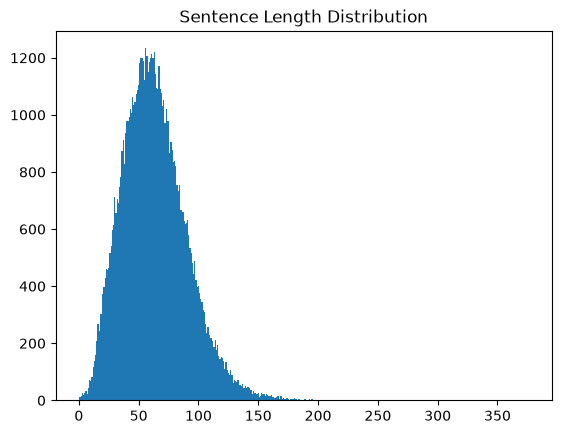

In [16]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거합니다.
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

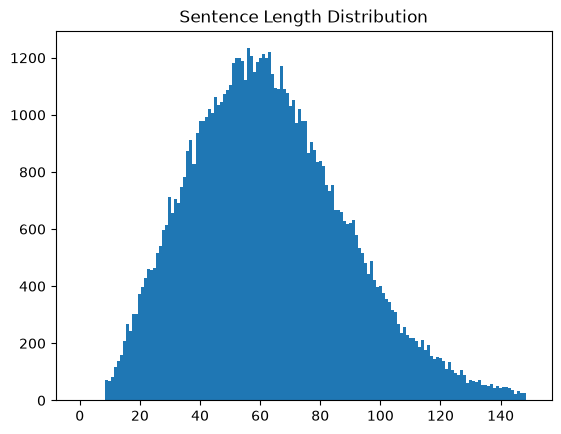

In [17]:
max_len = 150
min_len = 10

# 길이 조건에 맞는 문장만 선택합니다.
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

# 분포도를 다시 그려봅니다.
sentence_length = np.zeros((max_len), dtype=int)

for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

### 3. 공백 기반 토큰화

In [18]:
import torch
from torch.nn.utils.rnn import pad_sequence

class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        # 각 문장을 토큰화하여 단어 사전을 생성 (인덱스는 1부터 시작)
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        # 역방향 사전 생성
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            # 존재하지 않는 단어는 0으로 처리
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            # tensor인 경우 리스트로 변환
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            # 패딩 토큰(0)은 제외하고 디코딩
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

In [19]:
def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    # padding 토큰은 0
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [21]:
# 정제된 데이터 filtered_corpus를 공백 기반으로 토큰화하여 저장하는 코드를 직접 작성해 보세요.
split_corpus = []

for kor in filtered_corpus:
    split_corpus.append(kor.split())

In [22]:
len(split_corpus)

76908

In [23]:
split_tensor, split_tokenizer = tokenize(split_corpus)

print("Split Vocab Size:", len(split_tokenizer.index_word))

Split Vocab Size: 238305


In [25]:
for idx, word in enumerate(split_tokenizer.word_index):
    print(idx, ":", word)

    if idx > 10: break

0 : 이번
1 : 판결은
2 : 이란의
3 : 이러한
4 : 형벌
5 : 사용에
6 : 대한
7 : 인권
8 : 단체에
9 : 의해
10 : 신랄한
11 : 비난으로


### 4. 형태소 기반 토큰화

In [ ]:
# 위에서 사용한 코드를 활용해 MeCab 단어 사전을 만들어보세요.
# Hint : mecab.morphs()를 사용해서 형태소분석을 합니다.
# Windows에서는 MeCab.Tagger()를 사용하여 객체를 생성하고, parse() 메서드를 사용하여 문장을 형태소 단위로 분리할 수 있습니다.

# Windows MeCab 객체 생성
mecab = MeCab.Tagger()
def mecab_split(sentence):
    return mecab.parse(sentence).split()

mecab_corpus = []

for kor in filtered_corpus:
    mecab_corpus.append(mecab_split(kor))

In [32]:
mecab_tensor, mecab_tokenizer = tokenize(mecab_corpus)

print("MeCab Vocab Size:", len(mecab_tokenizer.index_word))

MeCab Vocab Size: 100665


In [33]:
# Case 1 : tokenizer.sequences_to_texts()

texts = mecab_tokenizer.sequences_to_texts([mecab_tensor[100]])
print(texts[0])

['AP', 'SL,*,*,*,*,*,*,*', '라디오', 'NNG,*,F,라디오,*,*,*,*', '뉴스', 'NNG,*,F,뉴스,*,*,*,*', ',', 'SC,*,*,*,*,*,*,*', '존', 'NNP,인명,T,존,*,*,*,*', '벨몬트', 'NNP,인명,F,벨몬트,*,*,*,*', '였', 'VCP+EP,*,T,였,Inflect,VCP,EP,이/VCP/*+었/EP/*', '습니다', 'EF,*,F,습니다,*,*,*,*', '.', 'SF,*,*,*,*,*,*,*', 'reunite', 'SL,*,*,*,*,*,*,*', '재결합', 'NNG,*,T,재결합,Compound,*,*,재/NNG/*+결합/NNG/행위', '하', 'XSV,*,F,하,*,*,*,*', '다', 'EC,*,F,다,*,*,*,*', 'EOS']


In [34]:
# Case 2 : tokenizer.index_word

sentence = ""

for w in mecab_tensor[100]:
    w = int(w)
    if w == 0: continue
    sentence += mecab_tokenizer.index_word[w] + " "

print(sentence)

AP SL,*,*,*,*,*,*,* 라디오 NNG,*,F,라디오,*,*,*,* 뉴스 NNG,*,F,뉴스,*,*,*,* , SC,*,*,*,*,*,*,* 존 NNP,인명,T,존,*,*,*,* 벨몬트 NNP,인명,F,벨몬트,*,*,*,* 였 VCP+EP,*,T,였,Inflect,VCP,EP,이/VCP/*+었/EP/* 습니다 EF,*,F,습니다,*,*,*,* . SF,*,*,*,*,*,*,* reunite SL,*,*,*,*,*,*,* 재결합 NNG,*,T,재결합,Compound,*,*,재/NNG/*+결합/NNG/행위 하 XSV,*,F,하,*,*,*,* 다 EC,*,F,다,*,*,*,* EOS 
